# <center>Machine learning for econometrics: double/debiased ML</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: econometrics</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Recognize the *partially linear model* $y = \theta_0 d + g_0(x) + \varepsilon$ as a generic structure in modern empirical work, and identify $\theta_0$ as the causal target of interest with $g_0$ a high-dimensional nuisance.

* Demonstrate by simulation that *naive plug-in*, estimating $g_0$ by an off-the-shelf ML method and substituting, produces a biased, slow-converging estimate of $\theta_0$, contaminated by the regularization bias of the ML estimator.

* State and prove (heuristically) that the *orthogonalized* score $\psi(W;\theta,\eta) = (Y - \ell_0(X) - \theta(D - m_0(X)))(D - m_0(X))$, with $\ell_0(x) = \mathbb{E}[Y\mid X = x]$ and $m_0(x) = \mathbb{E}[D\mid X = x]$, is Neyman-orthogonal: its derivative with respect to the nuisances $(\ell_0, m_0)$ vanishes at the truth, so first-order errors in $\hat\ell$ and $\hat m$ do not propagate into $\hat\theta$.

* Implement the Chernozhukov–Chetverikov–Demirer–Duflo–Hansen–Newey–Robins (2018) DDML estimator with $K$-fold cross-fitting, and see by Monte Carlo that it is consistent for $\theta_0$ where the naive estimators are not. The parametric $\sqrt{I}$ rate is recovered *despite* nuisances that converge more slowly, but not unconditionally: it requires the product-rate and regularity conditions of §3, and §5.2 shows that at $I = 500$ a finite-sample bias is still plainly visible.

* Apply DDML to the Mroz Mincer regression, using Lasso and Random Forest as alternative nuisance estimators, and contrast the resulting causal estimates with the naive OLS coefficient on education from Lecture 3.

### References

**[CCDDHNR]** Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., and Robins, J. (2018). 'Double/Debiased Machine Learning for Treatment and Structural Parameters'. *The Econometrics Journal*, 21(1), C1–C68.

**[N]** Neyman, J. (1959). 'Optimal Asymptotic Tests of Composite Hypotheses'. In *Probability and Statistics* (Cramér Festschrift), 213–234.

**[BC]** Belloni, A., Chernozhukov, V. (2013). 'Least Squares After Model Selection in High-Dimensional Sparse Models'. *Bernoulli*, 19(2), 521–547.

**[H]** Hansen, B. E. (2022). *Econometrics*. Princeton University Press. Chapter 29.

# Motivation: high-dimensional nuisances

* Most causal questions in empirical economics involve a small number of parameters of interest ($\theta$, often 1- or 2-dimensional) and a large number of nuisance functions ($g$, controlling for confounders). Lectures 3–7 handled the case where $g$ is parametric and low-dimensional, a handful of linear controls, and standard OLS or IV delivered the asymptotic theory.

* When $g$ depends on many controls, or on nonlinear / interaction terms of a few controls, OLS becomes unreliable for two reasons. With many controls, $X$ may not be full rank or may be poorly conditioned. With nonlinear $g$, the linear specification is misspecified, leading to bias in $\hat\theta$ that does not vanish with $I$.

* Machine learning estimators, Lasso, random forests, boosted trees, neural networks, are designed to estimate complex $g$ from moderate sample sizes, by trading some bias for reduced variance via regularization. They are inadequate as drop-in replacements for OLS in this context, but not primarily because of regularization: as §2 shows, plugging an estimated nuisance into a *non-orthogonal* score attenuates $\hat\theta$ even when that nuisance is known exactly. Regularization error then adds a second first-order term on top.

* The Double/Debiased Machine Learning (DDML) framework of Chernozhukov et al. (2018) reconciles ML estimation of $g$ with valid inference on $\theta$. The two key ingredients, Neyman-orthogonal moment conditions and sample-splitting (cross-fitting), together insulate the inference on $\theta$ from the first-order error in $\hat g$, recovering the parametric $\sqrt{I}$ rate. We develop the framework and apply it both to a synthetic DGP (where the truth is known) and to the Mroz Mincer regression.

## Loading our libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from types import SimpleNamespace
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.base import clone

rng = np.random.default_rng(777)
plt.rcParams['figure.figsize'] = (8, 4.5)


# 1. The partially linear model

## 1.1 Setup

Let $\{(Y_i, D_i, X_i)\}_{i=1}^I$ be i.i.d. observations with
$$
Y_i = \theta_0\,D_i + g_0(X_i) + \varepsilon_i, \qquad \mathbb{E}[\varepsilon_i\mid D_i, X_i] = 0,
$$
where $D_i\in\mathbb{R}$ is the *treatment* or focal regressor, $X_i\in\mathbb{R}^p$ is a (potentially high-dimensional) vector of controls, $g_0:\mathbb{R}^p\to\mathbb{R}$ is an unknown function (the *nuisance*), and $\theta_0\in\mathbb{R}$ is the parameter of interest. The treatment may itself depend on the controls:
$$
D_i = m_0(X_i) + \nu_i, \qquad \mathbb{E}[\nu_i\mid X_i] = 0.
$$
Under conditional unconfoundedness, $\mathbb{E}[\varepsilon_i\mid D_i, X_i] = 0$, $\theta_0$ is the *causal* effect of $D$ on $Y$.

## 1.2 Identification via Frisch–Waugh–Lovell

Recall from Lecture 3 the FWL theorem: $\theta_0$ in a *linear* regression can be recovered by first partialling out the controls (i.e., taking residuals of $Y$ and $D$ on $X$) and then regressing residuals on residuals. Generalizing to the partially linear model:

* Let $\tilde Y_i := Y_i - g_0(X_i) - \theta_0 m_0(X_i)$, but $g_0$ involves $\theta_0$, which we don't know. Use the equivalent
* $\tilde Y_i := Y_i - \mathbb{E}[Y_i\mid X_i] = Y_i - \ell_0(X_i)$, where $\ell_0(x) := g_0(x) + \theta_0 m_0(x)$.
* Similarly $\tilde D_i := D_i - m_0(X_i) = \nu_i$.

Then $\tilde Y_i = \theta_0\tilde D_i + \varepsilon_i$, a *simple* one-variable regression. The "true" $\theta_0$ is identified as the coefficient on $\tilde D$ in this oracle regression.

Our problem is that $\ell_0$ and $m_0$ are unknown nonparametric functions. Standard regression would estimate $\ell_0$ and $m_0$ by OLS on a parametric form (e.g., polynomial), but with many controls or nonlinear $g_0$, that approach fails. ML methods give better $\hat\ell$ and $\hat m$, but the naive plug-in $\hat\theta_I^{\text{plug}}$ computed from those estimates is biased.

# 2. Why naive plug-in fails

Suppose we take the moment condition defining $\theta_0$ in the partially linear model,
$$
\mathbb{E}\bigl[(Y - \theta D - g_0(X))\,D\bigr] = 0,
$$
and simply substitute an estimate of the nuisance function. Two things go wrong, and it is
worth separating them, because only one of them is about machine learning.

**The score is not orthogonal in the nuisance.** Perturb $g_0$ in a direction $h$, writing
$g_r = g_0 + r\,h$. The derivative of the moment at $r=0$ is
$$
\partial_r\,\mathbb{E}\bigl[(Y - \theta_0 D - g_r(X))\,D\bigr]\Big|_{r=0}
= -\,\mathbb{E}\bigl[h(X)\,D\bigr],
$$
which is generally nonzero: it vanishes for every direction $h$ only if
$\mathbb{E}[D\mid X] = 0$. (Note that the derivative retains the direction $h$: the Gateaux
derivative of a functional is itself a functional of $h$, not the scalar $-\mathbb{E}[D]$.) A
first-order error in $\hat g$ therefore moves the solution by a first-order amount.

**What the code below actually computes.** The nuisance we can estimate directly by regressing
$Y$ on $X$ is not $g_0$ but
$$
\ell_0(X) := \mathbb{E}[Y\mid X] = g_0(X) + \theta_0\,m_0(X),
$$
since $g_0$ is only separately identified once $\theta_0$ is known. The correct description
of the naive estimator implemented in `naive_plugin` is: fit $\hat\ell \approx \ell_0$, then
regress $Y - \hat\ell(X)$ on $D$ *without residualizing $D$*,
$$
\hat\theta^{\text{plug}}_I = \frac{\sum_i D_i\,\bigl(Y_i - \hat\ell(X_i)\bigr)}{\sum_i D_i^2}.
$$
Even with an **oracle** $\ell_0$ this is biased. Substituting $Y_i - \ell_0(X_i) =
\theta_0\nu_i + \varepsilon_i$ with $\nu = D - m_0(X)$ gives
$$
\hat\theta^{\text{plug}}_I \;\xrightarrow{p}\;
\theta_0\,\frac{\mathbb{E}[D\nu]}{\mathbb{E}[D^2]}
= \theta_0\,\frac{\operatorname{Var}(\nu)}{\operatorname{Var}(\nu) + \mathbb{E}[m_0(X)^2]},
$$
an attenuation toward zero governed by how much of the variation in $D$ the controls explain.
The denominator carries the full variance of $D$ while the numerator carries only its
residual part. In the simulation below $\operatorname{Var}(\nu) = 0.25$ against
$\mathbb{E}[m_0(X)^2] = 10/9$, so an oracle-$\ell_0$ plug-in would converge to
$0.5\times 0.25/(0.25 + 10/9) \approx 0.092$: badly attenuated from $\theta_0 = 0.5$ before
any estimation error enters at all. This is a *specification* failure, not a shrinkage
artefact: it does not go away with a better nuisance estimator.

Regularization error in $\hat\ell$ is a second, distinct first-order effect, and in this
design it happens to push the *other* way: an imperfect $\hat\ell$ leaves part of
$\theta_0 m_0(X)$ in the residual, which is positively correlated with $D$ and pulls the
estimate back up from $0.092$. The two errors do not cancel in any reliable way, their
relative size depends on the learner and the design, and neither is repaired by a better
learner. Both are removed by the same fix: replace the moment with one that is
**Neyman-orthogonal** in the nuisance, whose derivative with respect to the nuisance vanishes
in *every* direction at the truth, and residualize $D$ as well as $Y$.

# 3. The Neyman-orthogonal score

Consider the score
$$
\psi(W;\theta,\eta) = (Y - \ell_0(X) - \theta(D - m_0(X)))(D - m_0(X)), \qquad \eta := (\ell_0, m_0),
$$
where $\ell_0(x) = \mathbb{E}[Y\mid X = x]$ and $m_0(x) = \mathbb{E}[D\mid X = x]$. The corresponding moment condition is $\mathbb{E}[\psi] = 0$ at $(\theta_0, \eta_0)$.

---

**Theorem (Neyman orthogonality).** The score $\psi$ satisfies
$$
\left.\frac{\partial}{\partial r}\,\mathbb{E}\bigl[\psi(W;\theta_0, \eta_0 + r\Delta)\bigr]\right|_{r=0} = 0
$$
for any small perturbation $\Delta = (\delta_\ell, \delta_m)$ of the nuisance.

---

**Proof.** Write $\nu := D - m_0(X)$, so that $\mathbb{E}[\nu\mid X] = 0$, and note that $Y - \ell_0(X) = \theta_0\nu + \varepsilon$ with $\mathbb{E}[\varepsilon\mid X] = 0$. Differentiating $\psi = (Y - \ell(X) - \theta_0(D - m(X)))(D - m(X))$ along $\eta_0 + r\Delta$ and evaluating at $r = 0$:
$$
\partial_r\,\mathbb{E}[\psi]\big|_0 = -\mathbb{E}[\delta_\ell(X)\,\nu] \;-\; \mathbb{E}[\varepsilon\,\delta_m(X)] \;+\; \theta_0\,\mathbb{E}[\delta_m(X)\,\nu].
$$
Every term vanishes: the first and third since $\mathbb{E}[\nu\mid X] = 0$, and the second since $\mathbb{E}[\varepsilon\mid X] = 0$. $\square$

Orthogonality kills the first-order term, so what remains is the product of the two nuisance
errors. The condition the theory actually needs is
$$
\lVert\hat\ell - \ell_0\rVert \cdot \lVert\hat m - m_0\rVert = o_p\bigl(I^{-1/2}\bigr),
$$
a *product* rate, which is why the individual nuisances may converge more slowly than
$I^{-1/2}$. It is often summarised as "each nuisance needs $I^{-1/4}$", and that is the right
mental picture, but two qualifications matter. Rates of exactly $I^{-1/4}$ deliver a product
of order $O_p(I^{-1/2})$ rather than the $o_p(I^{-1/2})$ required, so the statement needs a
little room: slightly faster than $I^{-1/4}$, or one nuisance faster to compensate for the
other being slower. And such rates are *not* automatic: they hold for particular estimators
under substantive conditions on the problem, such as Lasso under approximate sparsity with a
well-behaved design, and can fail badly when those conditions do not hold. Given the product
condition, the surviving remainder is negligible and $\hat\theta$ is asymptotically Gaussian
with the standard semiparametric variance.

Within that proviso, $\hat\theta_{\text{DDML}}$ does not require any particular functional
form for $\ell_0$ or $m_0$: Lasso, random forests and neural networks are all admissible, and
the choice becomes an empirical question about which estimates the nuisances well enough.

# 4. Cross-fitting

A second concern, separate from Neyman orthogonality, is *overfitting*: the same data used to fit $\hat\ell$ and $\hat m$ also goes into the orthogonalized regression, generating spurious dependence that biases the variance of $\hat\theta$. The fix is **sample splitting**: estimate the nuisances on one subsample and apply them on a held-out subsample.

To regain full statistical efficiency, the construction is iterated as $K$-fold *cross-fitting*:

1. Partition $\{1,\dots,I\}$ randomly into $K$ folds $\mathcal{I}_1,\dots,\mathcal{I}_K$.
2. For each fold $k$:
   * Fit $\hat\ell_{(k)}$ and $\hat m_{(k)}$ on the complement $\mathcal{I}_k^c$ using any ML method.
   * Compute residuals on fold $k$: $\tilde Y_i := Y_i - \hat\ell_{(k)}(X_i)$ and $\tilde D_i := D_i - \hat m_{(k)}(X_i)$ for $i\in\mathcal{I}_k$.
3. Estimate $\theta$ by simple OLS of $\tilde Y$ on $\tilde D$ across all observations:
$$
\hat\theta_I^{\text{DDML}} = \frac{\sum_i \tilde Y_i\,\tilde D_i}{\sum_i \tilde D_i^2}.
$$
4. Asymptotic standard errors from the influence function:
$$
\widehat{\mathrm{Var}}(\hat\theta) = \frac{1}{I}\biggl(\frac{1}{I}\sum_i \tilde D_i^2\biggr)^{-2}\,\frac{1}{I}\sum_i\bigl(\tilde Y_i - \hat\theta\,\tilde D_i\bigr)^2\,\tilde D_i^2.
$$

(This is the same Eicker–White sandwich variance from Lecture 4, specialized to a one-variable regression.)

## 4.1 DIY implementation

In [2]:
def ddml(y_i, d_i, X_i_p, learner_y, learner_d, K=5, random_state=42):
    I = len(y_i)
    kf = KFold(n_splits=K, shuffle=True, random_state=random_state)
    yresid_i = np.zeros(I)
    dresid_i = np.zeros(I)
    for train_idx, test_idx in kf.split(np.arange(I)):
        ly = clone(learner_y); ld = clone(learner_d)
        ly.fit(X_i_p[train_idx], y_i[train_idx])
        ld.fit(X_i_p[train_idx], d_i[train_idx])
        yresid_i[test_idx] = y_i[test_idx] - ly.predict(X_i_p[test_idx])
        dresid_i[test_idx] = d_i[test_idx] - ld.predict(X_i_p[test_idx])
    # Orthogonalized regression: simple one-variable OLS through origin
    θ = (dresid_i @ yresid_i) / (dresid_i @ dresid_i)
    # HC0-type SE from the influence function
    ψ_i = (yresid_i - θ * dresid_i) * dresid_i
    var = (ψ_i ** 2).sum() / (dresid_i @ dresid_i) ** 2
    se = np.sqrt(var)
    return SimpleNamespace(θ=θ, se=se, yresid_i=yresid_i, dresid_i=dresid_i)

def naive_plugin(y_i, d_i, X_i_p, learner_y):
    # Fit ℓ̂ ≈ E[Y|X] on the full data, then regress y - ℓ̂(X) on d.
    # Note d is NOT residualized: that omission is what biases this estimator,
    # and it would bias it even if ℓ̂ were the oracle ℓ₀ (see §2).
    learner_y.fit(X_i_p, y_i)
    yresid_i = y_i - learner_y.predict(X_i_p)
    θ = (d_i @ yresid_i) / (d_i @ d_i)
    return θ


# 5. Simulation: DDML vs naive plug-in

We simulate from a partially linear DGP with $I = 1{,}000$ observations and $p = 20$ controls. The functions $g_0$ and $m_0$ are smooth nonlinear functions of $X$, and the true treatment effect is $\theta_0 = 0.5$. We compute three estimators:

1. **Naive OLS (linear)**: regress $Y$ on $(D, X)$ linearly. Gets the wrong answer because $g_0$ and $m_0$ are nonlinear.
2. **Naive plug-in ML**: fit $\hat\ell \approx \mathbb{E}[Y\mid X]$ on $(Y, X)$ via Lasso, then regress $Y - \hat\ell(X)$ on $D$: note $D$ itself is *not* residualized. Gets the wrong answer because the score is not Neyman-orthogonal, and §2 showed it would get the wrong answer even with an oracle $\ell_0$.
3. **DDML**: cross-fitted partialling-out as defined above, residualizing both $Y$ and $D$.

(The DGP is the one of §2, so the oracle attenuation computed there applies: a plug-in with a perfect $\hat\ell$ would converge to about $0.092$.)

> **Runtime.** Everything from here to the end of §5.2 is a Monte Carlo experiment with cross-fitted `LassoCV` inside every replication, and takes roughly **four to five minutes** end to end on a laptop: about three minutes for the main comparison and ninety seconds for the sample-size sweep. Nothing later in the notebook depends on §5.2, so it can be skipped on a first pass.

In [3]:
def simulate_pll(I=1_000, p=20, θ_true=0.5, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    X_i_p = rng.standard_normal((I, p))
    # m_0 and g_0 are smooth nonlinear functions of the same first-5 X_j;
    # OLS linear-in-X cannot capture them, so OLS suffers from omitted-variable bias.
    base_i = ((X_i_p[:, :5] ** 2 - 1)).sum(axis=1) / 3.0
    m_i = base_i
    g_i = 0.7 * base_i
    ν_i  = 0.5 * rng.standard_normal(I)
    ε_i  = 1.0 * rng.standard_normal(I)
    d_i  = m_i + ν_i
    y_i  = θ_true * d_i + g_i + ε_i
    return y_i, d_i, X_i_p

def make_learner(kind='lasso', degree=2):
    if kind == 'lasso':
        # Include polynomial basis so Lasso can capture quadratic / interaction nonlinearities.
        return Pipeline([
            ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('lasso',  LassoCV(cv=5, n_alphas=20, max_iter=20_000, n_jobs=-1)),
        ])
    elif kind == 'rf':
        return RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=0)
    else:
        raise ValueError(kind)

# Single replication
rng = np.random.default_rng(2026)
y_i, d_i, Xsim_i_p = simulate_pll(I=1_000, p=20, θ_true=0.5, rng=rng)

# 1. Naive linear OLS
W_i_p = np.column_stack([d_i[:, None], Xsim_i_p])
β_p = np.linalg.solve(W_i_p.T @ W_i_p, W_i_p.T @ y_i)
θ_ols_linear = β_p[0]

# 2. Naive plug-in with Lasso (polynomial basis)
θ_plugin = naive_plugin(y_i, d_i, Xsim_i_p, make_learner('lasso'))

# 3. DDML with Lasso (polynomial basis) for both nuisances
fit_ddml = ddml(y_i, d_i, Xsim_i_p, make_learner('lasso'), make_learner('lasso'), K=5)

print(f'Truth:                        θ_0 = 0.500')
print(f'Naive OLS (linear in X):      θ̂   = {θ_ols_linear:>7.4f}')
print(f'Naive plug-in (poly Lasso):   θ̂   = {θ_plugin:>7.4f}')
print(f'DDML (poly Lasso, 5-fold):    θ̂   = {fit_ddml.θ:>7.4f}  (s.e. {fit_ddml.se:.4f})')


Truth:                        θ_0 = 0.500
Naive OLS (linear in X):      θ̂   =  1.0868
Naive plug-in (poly Lasso):   θ̂   =  0.2064
DDML (poly Lasso, 5-fold):    θ̂   =  0.5834  (s.e. 0.0624)


In a single replication, DDML recovers $\theta_0 = 0.5$ within sampling noise, while the naive
plug-in is visibly biased downward. As §2 showed, that bias is not principally a
regularization artefact: the attenuation factor
$\operatorname{Var}(\nu)/\bigl(\operatorname{Var}(\nu)+\mathbb{E}[m_0(X)^2]\bigr)$, which
comes from regressing on $D$ rather than on its residual $\nu$, would by itself drag an
oracle-$\ell_0$ plug-in all the way down to about $0.092$. The estimate we actually see sits
*above* that, because an imperfect $\hat\ell$ leaves some of $\theta_0 m_0(X)$ in the residual
and pushes back up. Naive linear OLS misses in the other direction entirely: with $g_0$ and
$m_0$ both nonlinear in $X$, a linear control function leaves part of the confounding in the
error and biases $\hat\theta$ upward, well above $\theta_0$.

## 5.1 Monte Carlo: distribution of the three estimators

The single replication is suggestive. Let us examine bias and variance by Monte Carlo.

In [4]:
def one_replication(rng, I=500, p=20, θ_true=0.5):
    y_i, d_i, Xsim_i_p = simulate_pll(I=I, p=p, θ_true=θ_true, rng=rng)
    # Naive OLS linear
    W_i_p = np.column_stack([d_i[:, None], Xsim_i_p])
    θ_ols = np.linalg.solve(W_i_p.T @ W_i_p, W_i_p.T @ y_i)[0]
    # Naive plug-in with Lasso
    θ_plug = naive_plugin(y_i, d_i, Xsim_i_p, make_learner('lasso'))
    # DDML with Lasso
    fit = ddml(y_i, d_i, Xsim_i_p, make_learner('lasso'), make_learner('lasso'), K=5)
    return θ_ols, θ_plug, fit.θ

# Run a modest MC (full DDML is expensive — keep MC small but real)
rng = np.random.default_rng(2026)
M = 200
results = np.empty((M, 3))
for m in range(M):
    results[m] = one_replication(rng, I=500, p=20, θ_true=0.5)

θ_ols_mc, θ_plug_mc, θ_ddml_mc = results.T

print(f'Monte Carlo over M = {M} replications (I = 500, p = 20, θ_0 = 0.5):')
print(f"{'estimator':<24s}{'mean':>10s}{'bias':>10s}{'MCSE':>9s}{'bias/MCSE':>11s}"
      f"{'std':>9s}{'RMSE':>9s}")
for name, est in [('Naive OLS (linear)', θ_ols_mc),
                  ('Naive plug-in Lasso', θ_plug_mc),
                  ('DDML (Lasso, K = 5)',   θ_ddml_mc)]:
    bias = est.mean() - 0.5
    mcse = est.std(ddof=1) / np.sqrt(M)          # standard error OF THE MEAN, not of θ̂
    rmse = np.sqrt(((est - 0.5) ** 2).mean())
    print(f'{name:<24s}{est.mean():>10.4f}{bias:>+10.4f}{mcse:>9.4f}{bias/mcse:>11.1f}'
          f'{est.std(ddof=1):>9.4f}{rmse:>9.4f}')

print('\nThe MCSE column is the precision of each *mean*, so bias/MCSE says whether a bias is')
print('detectable at this M. None of the three means is within sampling noise of 0.5 — DDML')
print('included. §5.2 asks whether its bias is the kind that goes away.')


Monte Carlo over M = 200 replications (I = 500, p = 20, θ_0 = 0.5):
estimator                     mean      bias     MCSE  bias/MCSE      std     RMSE
Naive OLS (linear)          1.0718   +0.5718   0.0029      197.7   0.0409   0.5732
Naive plug-in Lasso         0.2284   -0.2716   0.0025     -106.9   0.0359   0.2739
DDML (Lasso, K = 5)         0.5589   +0.0589   0.0063        9.3   0.0891   0.1066

The MCSE column is the precision of each *mean*, so bias/MCSE says whether a bias is
detectable at this M. None of the three means is within sampling noise of 0.5 — DDML
included. §5.2 asks whether its bias is the kind that goes away.


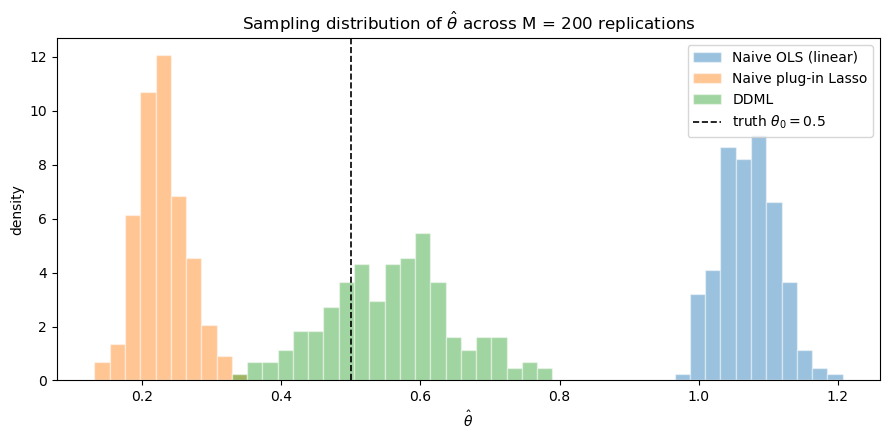

In [5]:
# Visualize the sampling distributions
fig, ax = plt.subplots(figsize=(9, 4.5))
bins_g = np.linspace(
    min(est.min() for est in (θ_ols_mc, θ_plug_mc, θ_ddml_mc)),
    max(est.max() for est in (θ_ols_mc, θ_plug_mc, θ_ddml_mc)),
    50,
)
for est, name, color in zip([θ_ols_mc, θ_plug_mc, θ_ddml_mc],
                             ['Naive OLS (linear)', 'Naive plug-in Lasso', 'DDML'],
                             ['C0', 'C1', 'C2']):
    ax.hist(est, bins=bins_g, density=True, alpha=0.45, label=name, edgecolor='white', color=color)
ax.axvline(0.5, color='k', ls='--', lw=1.2, label=r'truth $\theta_0 = 0.5$')
ax.set_xlabel(r'$\hat\theta$')
ax.set_ylabel('density')
ax.set_title(f'Sampling distribution of $\\hat\\theta$ across M = {M} replications')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


The three sampling distributions lead to the following comparison.

* **Naive OLS** is biased *upward*. With $g_0$ and $m_0$ nonlinear (here quadratic), partialling
  out $X$ only linearly leaves a residual correlation between $d$ and $g_0(X)$, which biases the
  implied $\hat\theta$.
* **Naive plug-in Lasso** is biased *downward*, and §2 identified the mechanism: regressing on
  unresidualized $D$ attenuates $\hat\theta$ toward zero by the factor
  $\operatorname{Var}(\nu)/(\operatorname{Var}(\nu)+\mathbb{E}[m_0^2])$, which for this DGP
  would drag an oracle-$\ell_0$ plug-in down to about $0.092$. The estimate here sits above that
  because an imperfect $\hat\ell$ leaves some of $\theta_0 m_0(X)$ in the residual and pushes
  back up. Regularization is a contributor, not the cause: the bias survives a perfect nuisance.
* **DDML** is much the closest to the truth, but it is *not* unbiased at this sample size: its
  mean is about nine Monte Carlo standard errors above $\theta_0$. Cross-fitted orthogonal
  partialling-out removes the first-order nuisance term; what is left is a second-order
  remainder, and at $I = 500$ with a 230-feature basis that remainder is visible.

The RMSE column quantifies the practical advantage: DDML's RMSE is roughly *one-fifth* that of
naive OLS. But the conclusion of this table is that all three estimators are measurably off
at $I = 500$, and the distinction that matters is what happens next, which is the subject of
§5.2.

## 5.2 Is the DDML bias a finite-sample effect?

The table above displays a finite-sample problem: DDML is biased by roughly $+0.06$, which at
$M = 200$ is about nine Monte Carlo standard errors: not something that can be waved away as
simulation noise. It would be wrong to call this estimator "approximately unbiased" on this
evidence.

Orthogonality does not promise finite-sample unbiasedness, and never did. What §3 established
is that the *first-order* nuisance term drops out, leaving a remainder that is second order in
the nuisance error. At $I = 500$, with $p = 20$ controls entering a degree-2 polynomial basis
of 230 features, that remainder is not small. The claim worth testing is therefore not
"unbiased at $I=500$" but **consistent**: does the bias vanish as $I$ grows?

That question separates DDML from the naive plug-in sharply, because the plug-in's bias is a
*probability limit*, §2 computed it as $\theta_0\operatorname{Var}(\nu)/(\operatorname{Var}(\nu)
+ \mathbb{E}[m_0^2]) \approx 0.092$, and a probability limit does not move when you collect
more data. So the two errors look similar in the table above and behave completely differently
as $I$ grows. The cell below runs DDML alone at increasing $I$ to see which pattern holds.

In [6]:
# DDML only (the two naive estimators are cheap but not the question here), at increasing I.
# Roughly 90 seconds; M is trimmed at larger I because the sampling spread shrinks too.
rng_sweep = np.random.default_rng(7)
sweep = []
for I_s, M_s in ((500, 100), (1_000, 100), (2_000, 60)):
    est_m = np.empty(M_s)
    for m in range(M_s):
        y_i, d_i, Xs_i_p = simulate_pll(I=I_s, p=20, θ_true=0.5, rng=rng_sweep)
        est_m[m] = ddml(y_i, d_i, Xs_i_p, make_learner('lasso'),
                        make_learner('lasso'), K=5).θ
    sweep.append((I_s, M_s, est_m.mean(), est_m.std(ddof=1) / np.sqrt(M_s)))

print(f"{'I':>7}{'M':>5}{'mean θ̂':>10}{'bias':>10}{'MCSE':>9}{'bias/MCSE':>11}")
for I_s, M_s, mean_s, mcse_s in sweep:
    print(f'{I_s:>7}{M_s:>5}{mean_s:>10.4f}{mean_s-0.5:>+10.4f}{mcse_s:>9.4f}'
          f'{(mean_s-0.5)/mcse_s:>11.1f}')

# The plug-in, by contrast, converges to a fixed wrong number. Its oracle plim from §2:
var_ν, E_m2 = 0.25, 10 / 9
print(f'\nfor comparison, the oracle plug-in plim from §2 = '
      f'{0.5 * var_ν / (var_ν + E_m2):.4f}  (independent of I)')

# Verification contract: the DDML bias must actually shrink, and must end up far smaller
# than the plug-in's asymptotic error. These are the claims the section makes.
bias_first, bias_last = abs(sweep[0][2] - 0.5), abs(sweep[-1][2] - 0.5)
plug_bias = abs(0.5 * var_ν / (var_ν + E_m2) - 0.5)
print(f'\n|bias| at I = {sweep[0][0]}: {bias_first:.4f}   at I = {sweep[-1][0]}: {bias_last:.4f}')
assert bias_last < 0.5 * bias_first, 'DDML bias did not fall materially with I'
assert bias_last < 0.25 * plug_bias, 'DDML bias is not small next to the plug-in plim'
print('Verification passed: the DDML bias shrinks with I; the plug-in error does not.')


      I    M   mean θ̂      bias     MCSE  bias/MCSE
    500  100    0.5595   +0.0595   0.0086        6.9
   1000  100    0.5433   +0.0433   0.0065        6.6
   2000   60    0.5178   +0.0178   0.0058        3.0

for comparison, the oracle plug-in plim from §2 = 0.0918  (independent of I)

|bias| at I = 500: 0.0595   at I = 2000: 0.0178
Verification passed: the DDML bias shrinks with I; the plug-in error does not.


# 6. Application to Mroz Mincer regression

We return to the Mroz Mincer regression that has run through Lectures 3, 5, and 10. The focal
regressor is education and the controls are experience, experience squared, and the demographic
variables used in the Heckman selection equation.

A word on what this exercise is and is not. DDML estimates the coefficient on education in a
partially linear model *given* the controls supplied; it does not provide exogeneity. The
identifying assumption in §1 was $\mathbb{E}[\varepsilon\mid D, X] = 0$, and unobserved ability
is precisely the classic reason to doubt it here: it is what motivated the instrumental
variables of Lecture 10. Nothing in the control list below addresses it. So read what follows
as a **flexible partial association**: the answer to "how much does the estimated
education–wage gradient move once the controls are allowed to enter in an arbitrary smooth
way rather than linearly?" That is a real and useful robustness question, and it is a
different question from the causal return to schooling. The challenge: entering these controls linearly imposes that $g_0$ is a low-order polynomial in $(\text{exper})$ and additive in the demographics. DDML allows us to test the robustness of $\hat\beta_{\text{educ}}$ against a much richer (data-driven) control function $\hat g$.

In [7]:
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/sampleSelection/Mroz87.csv'
try:
    mroz = pd.read_csv(url)                       # Rdatasets Mroz87 (needs a network)
except Exception:
    # Offline fallback: the identical Mroz (1987) data ships with the `wooldridge` package.
    import wooldridge
    mroz = (wooldridge.data('mroz')
            .rename(columns={'inlf': 'lfp', 'kidslt6': 'kids5', 'kidsge6': 'kids618'})
            .copy())
mroz = mroz.loc[mroz['lfp'] == 1].copy()
mroz['lwage'] = np.log(mroz['wage'])

y_i = mroz['lwage'].values
d_i = mroz['educ'].values.astype(float)
X_i_p = mroz[['exper', 'kids5', 'kids618', 'age', 'nwifeinc']].values
print(f'I = {len(y_i)},  p = {X_i_p.shape[1]} controls')

# 1. The Lecture 3 specification itself: lwage on educ, exper, exper²
Xlec3_i_p = np.column_stack([np.ones(len(y_i)), d_i, mroz['exper'].values, mroz['exper'].values ** 2])
θ_ols_lec3 = np.linalg.solve(Xlec3_i_p.T @ Xlec3_i_p, Xlec3_i_p.T @ y_i)[1]

# 2. OLS on the same controls DDML is given, entered linearly
Xfull_i_p = np.column_stack([np.ones(len(y_i)), d_i, X_i_p, mroz['exper'].values ** 2])
θ_ols_linear = np.linalg.solve(Xfull_i_p.T @ Xfull_i_p, Xfull_i_p.T @ y_i)[1]

# 3. DDML with Lasso for both nuisances
fit_lasso = ddml(y_i, d_i, X_i_p, make_learner('lasso'), make_learner('lasso'), K=5, random_state=0)

# 4. DDML with Random Forest for both nuisances
fit_rf = ddml(y_i, d_i, X_i_p, make_learner('rf'), make_learner('rf'), K=5, random_state=0)

print(f"\n{'estimator':<30s}{'β̂_educ':>10s}{'s.e.':>10s}")
print(f'{"OLS (Lecture 3 spec)":<30s}{θ_ols_lec3:>10.4f}{"—":>10s}')
print(f'{"OLS (DDML controls, linear)":<30s}{θ_ols_linear:>10.4f}{"—":>10s}')
print(f'{"DDML (Lasso, K = 5)":<30s}{fit_lasso.θ:>10.4f}{fit_lasso.se:>10.4f}')
print(f'{"DDML (Random Forest, K = 5)":<30s}{fit_rf.θ:>10.4f}{fit_rf.se:>10.4f}')


I = 428,  p = 5 controls



estimator                        β̂_educ      s.e.
OLS (Lecture 3 spec)              0.1075         —
OLS (DDML controls, linear)       0.0999         —
DDML (Lasso, K = 5)               0.0981    0.0146
DDML (Random Forest, K = 5)       0.0902    0.0150


Read the four rows as two separate steps. Adding the demographic controls, young and older children, age, non-wife income, to the Lecture 3 specification moves the education coefficient from $0.1075$ to $0.0999$; that is a change of *control set*, and has nothing to do with machine learning. Letting those same controls enter flexibly then moves it a little further: to $0.0981$ with Lasso, to $0.0902$ with Random Forest. Both DDML estimates sit within two thirds of a standard error ($\approx 0.015$) of the linear-controls OLS, and the whole spread across the four rows is barely more than one standard error.

The interpretation: for these data the linear specification of $g_0$ is close enough to adequate that flexible nuisance estimation does not overturn the headline number.

This is an empirical result, not imposed by the method. The exercise of running DDML to check the robustness of an OLS coefficient is a routine modern robustness check. In settings with truly nonlinear $g_0$ or many controls (think: thousands of zipcode dummies, or a rich set of interactions), the gap between OLS and DDML can be very large, and the OLS coefficient, even with the right asymptotic variance, would be biased.

# Looking ahead

DDML is a basic example of *orthogonal* moment conditions and of the broader program of *semiparametric inference with machine learning*. Three directions of generalization:

* **Heterogeneous treatment effects.** Replace the scalar $\theta_0$ with a function $\tau_0(X)$ representing the conditional average treatment effect. The Causal Forest of Wager and Athey (2018) and the R-learner of Nie and Wager (2021) extend DDML to this setting, using ML estimators that can capture rich heterogeneity in $\tau_0$.

* **Functional parameters.** Bach et al. (2024) and Foster and Syrgkanis (2023) extend the orthogonality / cross-fitting machinery to nonparametric and high-dimensional parameters of interest, blurring the boundary between econometrics and statistical learning theory.

* **Causal inference under unconfoundedness.** When conditional unconfoundedness fails, when there is unobserved confounding correlated with $D$, DDML alone is insufficient, but the framework combines naturally with IV (instrumental DDML), DiD (DDML with two-way fixed effects), and other identification strategies. The same orthogonality / cross-fitting principles apply.

The common principle, already present in the Eicker–White sandwich of Lecture 4 and the GMM result of Lecture 9, is that *valid* inference on a low-dimensional structural parameter is possible in the presence of high-dimensional nuisance components, provided one uses *orthogonal* moment conditions. DDML provides a direct illustration of this principle.

The next and final lecture (**Lecture 14, limited dependent variables**) obtains identification in a different way. Tobit and the Heckman correction handle a nuisance, the unobserved part of a censored or self-selected outcome, not by orthogonalizing against it but by assuming it away, through joint normality. The contrast is useful: DDML weakens what must be assumed about the nuisance and pays in sample splitting; the parametric selection models assume a great deal and pay when the assumption fails.